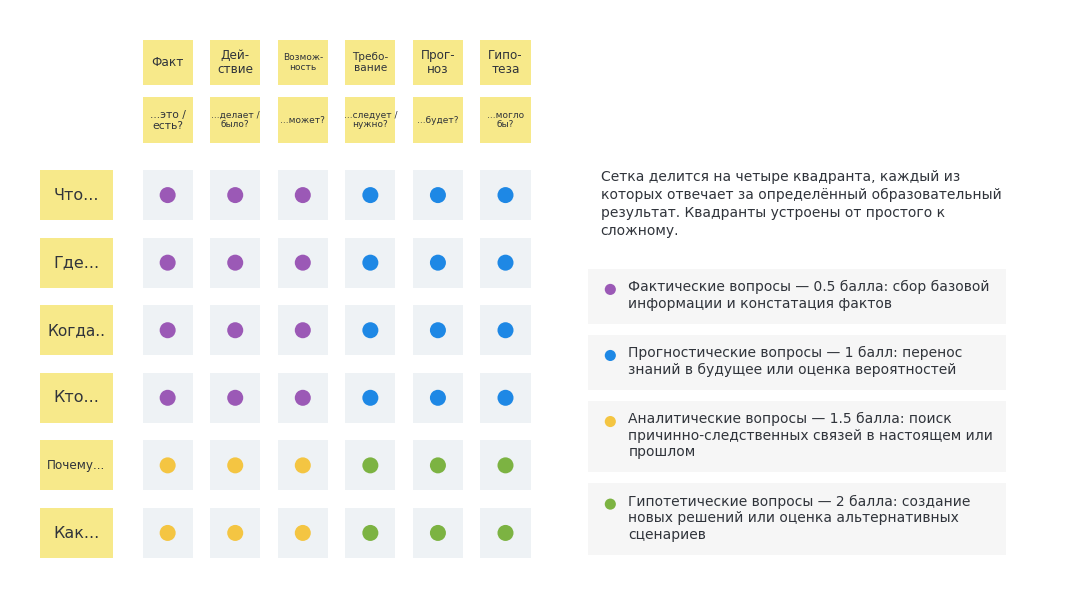

In [ ]:
# @title О формате дискуссии...
# pip install matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.text import Text
from matplotlib.font_manager import FontProperties
import matplotlib as mpl
from matplotlib.offsetbox import TextArea, HPacker, DrawingArea, AnnotationBbox
import textwrap


def wrap_cell(text, width=9, max_lines=3):
    """Wrap text to a fixed character width, respecting existing newlines."""
    parts = []
    for line in str(text).split("\n"):
        line = " ".join(line.split())
        if not line:
            parts.append("")
            continue
        parts.extend(textwrap.wrap(line, width=width, break_long_words=False, break_on_hyphens=False) or [""])
    if len(parts) > max_lines:
        parts = parts[:max_lines - 1] + ["…"]
    return "\n".join(parts)


def draw_question_grid(save_png="question_grid.png", save_svg="question_grid.svg", dpi=220):
    mpl.rcParams["font.family"] = "DejaVu Sans"  # кириллица ок

    # --- подписи ---
    # Добавляем явные переносы для верхних ячеек
    cols = ["Факт", "Дей-\nствие", "Возмож-\nность", "Требо-\nвание", "Прог-\nноз", "Гипо-\nтеза"]
    subcols = ["...это /\nесть?", "...делает /\nбыло?", "...может?", "...следует /\nнужно?", "...будет?", "...могло\nбы?"]
    rows = ["Что...", "Где...", "Когда..", "Кто...", "Почему...", "Как..."]

    # --- геометрия ---
    cell = 1.0
    gap = 0.35
    label_w = 1.45
    margin = 0.6

    n_cols, n_rows = len(cols), len(rows)
    grid_w = n_cols * cell + (n_cols - 1) * gap
    grid_h = n_rows * cell + (n_rows - 1) * gap

    y_grid0 = 0.8
    x_grid0 = margin + label_w + 0.6

    # УМЕНЬШАЕМ высоту верхних ячеек
    top_label_h = 0.9  # было label_w (1.45)
    y_sub = y_grid0 + grid_h + 0.55
    y_head = y_sub + top_label_h + 0.25  # уменьшили отступ

    # правая легенда
    legend_x = x_grid0 + grid_w + 1.4
    legend_w = 8.7
    legend_top = y_grid0 + grid_h - 0

    total_w = legend_x + legend_w + margin
    total_h = y_head + top_label_h + margin

    fig = plt.figure(figsize=(total_w * 0.65, total_h * 0.65))
    ax = plt.gca()
    ax.set_xlim(0, total_w)
    ax.set_ylim(0, total_h)
    ax.set_aspect("equal")
    ax.axis("off")

    # --- цвета ---
    sticky = "#F7E98A"
    grid_bg = "#EEF2F5"
    purple = "#9B59B6"  # 2 балла
    blue = "#1E88E5"    # 3 балла
    orange = "#F4C542"  # 5 баллов
    green = "#7CB342"   # 8 баллов
    text = "#30343B"

    def box(x, y, w, h, fc):
        ax.add_patch(Rectangle((x, y), w, h, facecolor=fc, edgecolor=fc, linewidth=0))

    def dot(x, y, r, c):
        ax.add_patch(Circle((x, y), r, facecolor=c, edgecolor=c, linewidth=0))

    def text_in_box(x, y, w, h, label, fontsize, min_fontsize=6.5,
                    pad=0.12, rotation=0):
        """Draw centered text and shrink it only when it does not fit the box."""
        artist = ax.text(
            x + w / 2, y + h / 2, label,
            ha="center", va="center", fontsize=fontsize,
            color=text, linespacing=1.1, rotation=rotation
        )
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        bbox = artist.get_window_extent(renderer=renderer)
        p0 = ax.transData.transform((x + pad, y + pad))
        p1 = ax.transData.transform((x + w - pad, y + h - pad))
        available_w = p1[0] - p0[0]
        available_h = p1[1] - p0[1]
        scale = min(1, available_w / max(bbox.width, 1), available_h / max(bbox.height, 1))
        artist.set_fontsize(max(min_fontsize, fontsize * scale * 0.96))
        return artist

    # --- верхние стикеры (2 ряда) ---
    for c in range(n_cols):
        x = x_grid0 + c * (cell + gap)

        box(x, y_head, cell, top_label_h, sticky)
        text_in_box(x, y_head, cell, top_label_h, cols[c], fontsize=9, rotation=0)

        box(x, y_sub, cell, top_label_h, sticky)
        text_in_box(x, y_sub, cell, top_label_h, subcols[c], fontsize=9, rotation=0)

    # --- левые стикеры (по строкам) ---
    for r in range(n_rows):
        y = y_grid0 + (n_rows - 1 - r) * (cell + gap)
        box(margin, y, label_w, cell, sticky)
        text_in_box(margin, y, label_w, cell, rows[r], fontsize=12, min_fontsize=8)

    # --- клетки + точки (4 квадранта) ---
    for r in range(n_rows):
        for c in range(n_cols):
            x = x_grid0 + c * (cell + gap)
            y = y_grid0 + (n_rows - 1 - r) * (cell + gap)
            box(x, y, cell, cell, grid_bg)

            if r <= 3 and c <= 2:
                col = purple
            elif r <= 3 and c >= 3:
                col = blue
            elif r >= 4 and c <= 2:
                col = orange
            else:
                col = green

            dot(x + cell / 2, y + cell / 2, 0.16, col)



    def wrap_to_px(text, max_width_px, renderer, fontprops, fig):
        """Greedy word-wrap to fit in max pixel width."""
        words = " ".join(str(text).split()).split(" ")
        if not words:
            return ""
        lines = []
        cur = words[0]
        t = Text(0, 0, "", fontproperties=fontprops)
        t.set_figure(fig)
        for w in words[1:]:
            cand = cur + " " + w
            t.set_text(cand)
            w_px = t.get_window_extent(renderer=renderer).width
            if w_px <= max_width_px:
                cur = cand
            else:
                lines.append(cur)
                cur = w
        lines.append(cur)
        return "\n".join(lines)

    # --- легенда справа (перенос по ширине) ---
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    fp10 = FontProperties(family="DejaVu Sans", size=10)

    x0_px = ax.transData.transform((legend_x, 0))[0]
    x1_px = ax.transData.transform((legend_x + legend_w - 0.6, 0))[0]
    avail_intro_px = max(50, x1_px - x0_px)

    dot_w_px = 14
    sep_px = 6
    avail_item_px = max(50, avail_intro_px - dot_w_px - sep_px)

    intro = (
        "Сетка делится на четыре квадранта, каждый из которых отвечает за определённый "
        "образовательный результат. Квадранты устроены от простого к сложному."
    )
    intro_wrapped = wrap_to_px(intro, avail_intro_px, renderer, fp10, fig)
    ax.text(legend_x, legend_top, intro_wrapped, ha="left", va="top",
            fontsize=10, color=text, linespacing=1.35)

    items = [
        (purple, "Фактические вопросы — 0.5 балла: сбор базовой информации и констатация фактов"),
        (blue,   "Прогностические вопросы — 1 балл: перенос знаний в будущее или оценка вероятностей"),
        (orange, "Аналитические вопросы — 1.5 балла: поиск причинно-следственных связей в настоящем или прошлом"),
        (green,  "Гипотетические вопросы — 2 балла: создание новых решений или оценка альтернативных сценариев"),
    ]

    # параметры в data-units (можно слегка подкрутить под вкус)
    line_h = 0.33
    pad_y = 0.22
    gap_y = 0.22
    pad_left = 0.25

    intro_lines = intro_wrapped.count("\n") + 1
    y_top = legend_top - (intro_lines * line_h + 0.65)

    for color, line in items:
        wrapped = wrap_to_px(line, avail_item_px, renderer, fp10, fig)
        n_lines = wrapped.count("\n") + 1
        rect_h = pad_y * 2 + n_lines * line_h

        ax.add_patch(Rectangle((legend_x - pad_left, y_top - rect_h),
                              legend_w - 0.35, rect_h, facecolor="#F6F6F6", edgecolor="none"))

        da = DrawingArea(14, 14, 0, 0)
        da.add_artist(Circle((7, 7), 4, facecolor=color, edgecolor=color, linewidth=0))

        ta = TextArea(wrapped, textprops=dict(color=text, fontsize=10, fontproperties=fp10, linespacing=1.25))
        h = HPacker(children=[da, ta], align="top", pad=0, sep=6)

        ax.add_artist(AnnotationBbox(h, (legend_x, y_top - pad_y),
                                    xycoords="data", frameon=False, box_alignment=(0, 1)))

        y_top -= rect_h + gap_y

if __name__ == "__main__":
    draw_question_grid("question_grid.png", "question_grid.svg", dpi=240)

# Семинар 3. Торговые данные и товарный кейс: мороженое

В этом блокноте мы разбираем четыре шага анализа экспортного товара: макроэкономический фон, торговый баланс, товарную торговлю по странам-покупателям и сравнение уровней товарной классификации. Все шаги показаны на учебном примере российского экспорта мороженого.

Код не использует заранее внесённые числовые таблицы. Все значения загружаются из открытых источников:

- World Bank API: `https://api.worldbank.org/v2/`;
- OEC API на данных BACI/CEPII: `https://api-v2.oec.world/tesseract/`;
- описание набора BACI/CEPII, на который ссылается OEC: `http://www.cepii.fr/CEPII/en/bdd_modele/presentation.asp?id=37`.

В товарной части ниже есть функции загрузки данных. Их можно использовать как учебную опору: руками писать такие запросы с нуля на третьей неделе не нужно. Но расчёт для домашки всё равно придётся адаптировать под свой товар, свой период, свой источник и свои ограничения данных.

## Связь с лонгридом и домашним заданием

Лонгрид недели 3 даёт карту источников торговых данных и объясняет, почему важны уровень HS, проверка выгрузки и ограничения источника. Семинар превращает эту карту в рабочую последовательность действий: получить данные, проверить таблицу, посчитать показатели и отделить общий макроэкономический фон от вывода по конкретному товару.

Домашнее задание устроено по той же логике, но без готового товара: вместо мороженого нужно выбрать собственный российский товар, повторить диагностику, динамику и географию, а затем перенести содержательные выводы в `w3_hw.tex`.

## Как работать с кодом в этом блокноте

На этой неделе не нужно писать загрузчики API с нуля. Рабочая стратегия такая.

1. Сначала запусти блокнот сверху вниз и посмотри, какие таблицы появляются.
2. Функции-загрузчики можно воспринимать как готовые инструменты: важно понять, какие параметры они принимают и какую таблицу возвращают.
3. Менять стоит маленькие ячейки с параметрами: страна, товар, год, уровень HS.
4. После каждой загрузки проверяй размер таблицы, названия столбцов и пропуски.
5. Если запрос вернул пустую таблицу, сначала проверь код товара, год и страну, а не переписывай весь код.

Цель семинара — научиться читать торговую таблицу и задавать к ней правильные вопросы. Синтаксис Python здесь вторичен.


## Задача 1. Макроэкономические данные: экспорт и инфляция

На первом шаге посмотри на общий экономический фон стран, которые могут быть важны для торговли мороженым. В примере используются Россия, Казахстан и Беларусь.

Что нужно сделать.

1. Загрузи из World Bank показатель экспорта товаров и услуг в постоянных ценах: `NE.EXP.GNFS.KD`.
2. Загрузи из World Bank годовую инфляцию: `FP.CPI.TOTL.ZG`.
3. Проверь структуру обеих таблиц: названия столбцов, типы данных, годы, пропуски.
4. Объедини таблицы по стране и году.
5. Построй графики экспорта в обычной и логарифмической шкалах.
6. Посчитай годовой темп роста экспорта.
7. Определи страну и год с максимальным абсолютным объёмом экспорта.
8. Коротко сформулируй, как общий экспортный фон может повлиять на интерпретацию анализа мороженого.

На выходе у тебя должны быть:

- две исходные таблицы с понятными названиями столбцов;
- объединённая таблица `df_merged`;
- графики динамики экспорта;
- таблица с темпами роста;
- текстовый вывод о стране и годе с максимальным экспортом.

**Рамка аккуратного результата.**

| Country | Year | Exports_const_usd | Inflation_pct | Export_growth_pct | Что это даёт для анализа товара |
|---|---:|---:|---:|---:|---|
| [Страна] | [Год] | [Экспорт] | [Инфляция] | [Темп роста] | [Фон спроса / осторожность / повод проверить товар отдельно] |

Хороший вывод не переносит макропоказатель напрямую на мороженое. Он объясняет, какую рамку задаёт общий экспортный фон и почему для вывода по товару всё равно нужны данные по конкретному HS-коду.

**Рабочие ячейки**

Сначала запусти служебную ячейку ниже. В ней лежат импорты и функция для загрузки показателей World Bank. Её не нужно переписывать.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

# В семинаре смотрим три страны: экспортёра и два близких рынка для сравнения
COUNTRIES = ["RUS", "KAZ", "BLR"]
COUNTRY_NAMES_RU = {
    "RUS": "Россия",
    "KAZ": "Казахстан",
    "BLR": "Беларусь",
}

WORLD_BANK_BASE_URL = "https://api.worldbank.org/v2"
START_YEAR = 2018


def load_wb_indicator(countries, indicator, start_year=START_YEAR):
    """
    Загружает один показатель World Bank для списка стран.

    countries — список ISO3-кодов стран, indicator — код показателя World Bank,
    start_year — первый год, который оставляем в таблице.
    На выходе: country_code, country, year, value, indicator и source_url
    """
    # World Bank принимает несколько стран в одной строке через точку с запятой
    country_string = ";".join(countries)
    url = f"{WORLD_BANK_BASE_URL}/country/{country_string}/indicator/{indicator}"
    params = {
        "format": "json",
        "per_page": 20000,
    }

    # Сохраняем фактический URL ответа: его можно потом указать как проверяемый источник
    # requests.get(...) отправляет запрос; raise_for_status() сразу покажет ошибку API
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    payload = response.json()
    # payload[1] — список наблюдений World Bank: одна строка на страну и год

    rows = []
    for item in payload[1]:
        value = item["value"]
        year = int(item["date"])
        country_code = item["countryiso3code"]

        # Пропускаем пустые значения и слишком старые годы, чтобы графики не расползались
        if value is None or year < start_year:
            continue

        rows.append(
            {
                "country_code": country_code,
                "country": COUNTRY_NAMES_RU.get(country_code, item["country"]["value"]),
                "year": year,
                "value": value,
                "indicator": indicator,
                "source_url": response.url,
            }
        )

    # На выходе каждая строка — страна, год и значение одного показателя
    return pd.DataFrame(rows).sort_values(["country", "year"]).reset_index(drop=True)

In [ ]:
# Задача 1. Шаг 1: загрузи два показателя World Bank
#
# Подсказка:
# - экспорт в постоянных ценах: "NE.EXP.GNFS.KD"
# - инфляция: "FP.CPI.TOTL.ZG"
# - функция: load_wb_indicator(...)
#
# Ожидаемые имена таблиц:
# df_exports
# df_inflation


In [ ]:
# Задача 1. Шаг 2: проверь структуру таблиц
#
# Что посмотреть:
# - первые строки
# - типы столбцов
# - пропуски
# - какие годы попали в данные


In [ ]:
# Задача 1. Шаг 3: объедини экспорт и инфляцию по стране и году
#
# Ожидаемое имя результата:
# df_merged


In [ ]:
# Задача 1. Шаг 4: построй два графика экспорта
#
# Первый график: обычная шкала
# Второй график: логарифмическая шкала


In [ ]:
# Задача 1. Шаг 5: посчитай годовой темп роста экспорта
#
# Подсказка: нужен расчёт внутри каждой страны


In [ ]:
# Задача 1. Шаг 6: найди страну и год с максимальным объёмом экспорта
#
# После расчёта сформулируй короткий вывод: почему общий масштаб экономики
# нельзя напрямую переносить на товарный кейс


## Задача 2. Торговый баланс

Теперь сравни экспорт и импорт товаров и услуг. Это не показатель по мороженому, а общий фон: он помогает понять, находится ли страна в ситуации устойчивого внешнеторгового профицита или дефицита.

Что нужно сделать.

1. Загрузи из World Bank экспорт товаров и услуг в текущих долларах: `NE.EXP.GNFS.CD`.
2. Загрузи из World Bank импорт товаров и услуг в текущих долларах: `NE.IMP.GNFS.CD`.
3. Объедини таблицы по стране и году.
4. Рассчитай торговый баланс: экспорт минус импорт.
5. Переведи экспорт, импорт и баланс в миллиарды долларов.
6. Построй график торгового баланса по странам.
7. Рассчитай среднее значение и стандартное отклонение торгового баланса для каждой страны.
8. Найди страны и годы с положительным торговым балансом.
9. Объясни, почему общий торговый баланс нельзя напрямую переносить на выводы о рынке мороженого.

На выходе у тебя должны быть:

- таблица `df_trade`;
- столбцы `exports_bln_usd`, `imports_bln_usd`, `trade_balance_bln_usd`;
- график торгового баланса;
- сводные таблицы по среднему значению, разбросу и годам профицита;
- короткая интерпретация.

**Рамка аккуратного результата.**

| Country | Avg_trade_balance_bln_usd | Years_with_surplus | Как использовать в интерпретации |
|---|---:|---:|---|
| [Страна] | [Средний баланс] | [Число лет профицита] | [Общий фон / ограничение / причина не делать вывод по товару напрямую] |

Здесь важно явно написать, где заканчивается макроэкономический фон и начинается отдельная проверка конкретного HS-кода.

In [ ]:
# Задача 2. Шаг 1: загрузи экспорт и импорт товаров и услуг в текущих долларах
#
# Показатели:
# - экспорт: "NE.EXP.GNFS.CD"
# - импорт: "NE.IMP.GNFS.CD"
#
# Ожидаемые имена таблиц:
# df_exports_current
# df_imports_current


In [ ]:
# Задача 2. Шаг 2: объедини экспорт и импорт по стране и году
#
# Ожидаемое имя результата:
# df_trade


In [ ]:
# Задача 2. Шаг 3: рассчитай торговый баланс
#
# Формула:
# торговый баланс = экспорт – импорт
#
# Переведи экспорт, импорт и баланс в миллиарды долларов


In [ ]:
# Задача 2. Шаг 4: построй график торгового баланса по странам
#
# Не забудь добавить горизонтальную линию на уровне 0


In [ ]:
# Задача 2. Шаг 5: рассчитай среднее значение, разброс
# и годы с положительным торговым балансом


In [ ]:
# Задача 2. Шаг 6: сформулируй вывод
#
# Вопрос: почему общий торговый баланс не отвечает на вопрос
# про экспорт конкретного товара?


## Задача 3. Реальные торговые данные по мороженому

В этой задаче нужно получить таблицу стран-покупателей, очистить её, посчитать доли и построить диаграмму. Чтобы решение было воспроизводимым без ручного файла, ниже используется открытый OEC API на базе BACI/CEPII.

Мы оставляем функции-загрузчики, потому что их задача техническая: аккуратно получить данные и сохранить ссылку на запрос. Содержательная часть ограничена одним демонстрационным примером: Россия, `HS 210500`, последний доступный год.

Что нужно сделать на семинаре.

1. Найти в справочнике OEC идентификатор России как экспортёра.
2. Найти в справочнике OEC идентификатор товара `HS 210500`.
3. Определить последний доступный год в наборе BACI.
4. Загрузить экспорт российского мороженого по странам-покупателям за один год.
5. Проверить структуру ответа.
6. Рассчитать долю каждой страны-покупателя.
7. Построить диаграмму крупнейших направлений.

На выходе у тебя должны быть таблица стран-покупателей, ссылка на фактический API-запрос и диаграмма.

**Рамка таблицы стран-покупателей.**

| Partner | Export_value | Share_pct | Вопрос для обсуждения |
|---|---:|---:|---|
| [Страна-покупатель] | [Стоимость] | [Доля] | [Это базовый рынок, возможный рост, концентрация или случайный малый поток?] |
| [Страна-покупатель] | [Стоимость] | [Доля] | [Вопрос] |
| [Страна-покупатель] | [Стоимость] | [Доля] | [Вопрос] |

Рядом с таблицей должна остаться ссылка на фактический API-запрос. Комментарий к таблице должен объяснять не «товар перспективен», а какие рынки и ограничения стоит проверить дальше.

Служебные ячейки ниже можно запускать без изменений. Они нужны, чтобы не писать запросы к OEC с нуля.


In [ ]:
OEC_BASE_URL = "https://api-v2.oec.world/tesseract"
OEC_CUBE = "trade_i_baci_a_17"


def load_oec_members(level, search=None, limit="100,0"):
    """
    Загружает справочник OEC: страны, товары или годы

    Примеры справочников:
    - "Exporter Country" — страны-экспортёры
    - "Importer Country" — страны-импортёры
    - "HS6" — товары на уровне HS6
    - "Year" — доступные годы
    """
    # В справочниках OEC сначала ищем технические идентификаторы, а не сами торговые потоки
    # level выбирает справочник, search сужает поиск, limit задаёт число строк и смещение
    params = {
        "cube": OEC_CUBE,
        "level": level,
        "limit": limit,
    }
    if search is not None:
        params["search"] = search

    response = requests.get(
        f"{OEC_BASE_URL}/members.jsonrecords",
        params=params,
        timeout=60,
    )
    response.raise_for_status()

    payload = response.json()
    # Превращаем список members в таблицу, чтобы её можно было фильтровать через pandas
    table = pd.DataFrame(payload["members"])

    if table.empty:
        print("Справочник загрузился, но строк нет. Проверь level и search.")

    # Возвращаем и таблицу, и URL запроса: URL нужен для проверки источника
    return table, response.url


def load_oec_data(drilldowns, include, limit=5000):
    """
    Загружает таблицу OEC с торговыми потоками

    drilldowns — какие измерения нужны в таблице
    include — какие фильтры применить
    limit — сколько строк максимум запросить
    """
    # drilldowns задают столбцы результата, include ограничивает страну, год и товар
    # В домашке эти два списка меняются под выбранный товар и период
    params = {
        "cube": OEC_CUBE,
        "drilldowns": ",".join(drilldowns),
        "measures": "Trade Value",
        "include": ";".join(include),
        "locale": "en",
        "parents": "false",
        "limit": f"{limit},0",
    }

    response = requests.get(
        f"{OEC_BASE_URL}/data.jsonrecords",
        params=params,
        timeout=120,
    )
    response.raise_for_status()

    payload = response.json()
    # В data лежит сама торговая таблица; annotations помогают сослаться на источник данных
    table = pd.DataFrame(payload["data"])

    if table.empty:
        print("Запрос сработал, но таблица пустая. Проверь страну, год и код товара.")

    # annotations хранят метаданные ответа, а response.url — воспроизводимую ссылку на запрос
    return table, payload.get("annotations", {}), response.url

In [ ]:
def inspect_trade_table(df, title="таблица"):
    """Короткая диагностика: размер, типы, пропуски и число уникальных значений"""
    # Эта функция ничего не чистит; она показывает, где могут быть проблемы в таблице
    print(f"{title}: {df.shape[0]} строк, {df.shape[1]} столбцов")
    return pd.DataFrame(
        {
            "column": df.columns,
            "dtype": [df[column].dtype for column in df.columns],
            "missing": [df[column].isna().sum() for column in df.columns],
            "unique_values": [df[column].nunique(dropna=True) for column in df.columns],
        }
    )


def rank_trade_rows(df, name_column, value_column="Trade Value", n=10):
    """
    Делает простую таблицу лидеров

    Важно: это доли внутри уже загруженного среза, а не доли во всей мировой торговле
    """
    # Сначала суммируем стоимость по выбранной колонке, затем сортируем рынки по убыванию
    ranked = (
        df.groupby(name_column, as_index=False)[value_column]
        .sum()
        .sort_values(value_column, ascending=False)
        .reset_index(drop=True)
    )
    # Доля считается внутри текущего среза: например, внутри экспорта России по одному HS-коду
    ranked["share_in_slice_percent"] = ranked[value_column] / ranked[value_column].sum() * 100
    return ranked.head(n)


def draw_ranked_bar(df, name_column, value_column, title, scale=1e6, xlabel="млн долл. США"):
    """Строит горизонтальную диаграмму для уже подготовленной таблицы лидеров"""
    # Для горизонтальной диаграммы удобно сортировать по возрастанию: крупнейший столбец окажется сверху
    plot_df = df.sort_values(value_column)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(plot_df[name_column], plot_df[value_column] / scale)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis="x", alpha=0.3)
    plt.show()


In [ ]:
# Задача 3. Шаг 1: задай параметры демонстрационного запроса
#
# Оставь мороженое для семинара
# DEMO_EXPORTER_SEARCH = "Russia"
# DEMO_PRODUCT_SEARCH = "ice cream"
# DEMO_PRODUCT_NAME_FRAGMENT = "Ice cream"
# DEMO_HS6_CODE = "210500"
#
# Затем найди идентификаторы страны, товара и последний доступный год
# через load_oec_members(...)


In [ ]:
# Задача 3. Шаг 2: загрузи таблицу стран-покупателей через load_oec_data(...)
#
# Нужные измерения:
# "Year", "Exporter Country", "Importer Country", "HS6"
#
# Ожидаемое имя таблицы:
# demo_icecream


In [ ]:
# Задача 3. Шаг 3: проверь таблицу
#
# Используй inspect_trade_table(...)
# Посмотри, сколько строк, какие столбцы и есть ли пропуски


In [ ]:
# Задача 3. Шаг 4: сделай таблицу крупнейших стран-покупателей
#
# Используй rank_trade_rows(...)
# Затем посмотри доли стран внутри загруженного среза


In [ ]:
# Задача 3. Шаг 5: построй горизонтальную диаграмму
#
# Используй draw_ranked_bar(...)


Обрати внимание на границу между семинаром и домашкой. Здесь функции помогают получить данные, но сам анализ ограничен одним срезом за один год. В домашке нужно будет самостоятельно определить товар, период, источник, ограничения данных и итоговые показатели.


## Задача 4. Данные международной торговли через OEC

В этой части мы смотрим, как через OEC получить данные по разным уровням товарной детализации и сравнить агрегирование. Загрузчик уровней HS остаётся готовым, чтобы фокус был на смысле классификации, а не на синтаксисе API.

Что нужно сделать.

1. Получить три отдельных среза OEC для российского экспорта за последний доступный год: `HS2`, `HS4`, `HS6`.
2. Посмотреть, сколько товарных групп есть на каждом уровне.
3. Сравнить крупнейшие группы на разных уровнях.
4. Найти строку по `HS 210500`.
5. Объяснить, почему выводы по `HS2`, `HS4` и `HS6` могут различаться.

На выходе у тебя должны быть три таблицы, ссылки на фактические запросы и короткая интерпретация.

**Рамка сравнения уровней HS.**

| level | Rows | Что видно на этом уровне | Что нельзя утверждать |
|---|---:|---|---|
| HS2 | [Число групп] | [Широкая товарная область] | [Вывод по конкретному товару] |
| HS4 | [Число групп] | [Более близкая товарная группа] | [Точный вывод по HS6 без проверки] |
| HS6 | [Число групп] | [Конкретный товарный код] | [Рыночную стратегию без динамики и географии] |

Хорошая интерпретация показывает, как меняется смысл данных при переходе от широкого раздела к конкретному товару.

Служебная ячейка ниже добавляет функции для уровней `HS2`, `HS4` и `HS6`. Её можно запускать без изменений.


In [ ]:
def add_oec_code_column(df, hs_level):
    """Добавляет короткий читаемый HS-код из технического ID OEC"""
    result = df.copy()
    digits = int(hs_level.replace("HS", ""))
    id_column = f"{hs_level} ID"
    # В OEC ID может быть длиннее самого кода, поэтому берём последние 2/4/6 цифр
    result[f"{hs_level} Code"] = (
        result[id_column].astype(int).astype(str).str[-digits:].str.zfill(digits)
    )
    return result


def load_oec_level(hs_level):
    """
    Загружает российский экспорт за выбранный год на уровне HS2, HS4 или HS6.
    Используется, чтобы увидеть, как меняется детализация товара на разных уровнях HS
    """
    table, annotations, url = load_oec_data(
        drilldowns=["Year", "Exporter Country", hs_level],
        include=[
            f"Exporter Country:{russia_oec_id}",
            f"Year:{latest_oec_year}",
        ],
        limit=10000,
    )
    return add_oec_code_column(table, hs_level), annotations, url


def summarize_hs_depth(hs_tables):
    """Сравнивает, сколько товарных групп видно на разных уровнях HS"""
    rows = []
    for hs_level, table in hs_tables.items():
        # Каждая строка summary — один уровень классификации и общий объём экспорта в нём
        rows.append(
            {
                "level": hs_level,
                "product_groups": table[f"{hs_level} Code"].nunique(),
                "trade_value_usd": table["Trade Value"].sum(),
            }
        )
    return pd.DataFrame(rows)


def rank_hs_groups(table, hs_level, n=10):
    """Показывает крупнейшие товарные группы на выбранном уровне HS"""
    code_column = f"{hs_level} Code"
    # Группируем по коду и названию, потому что один уровень HS содержит много строк экспорта
    result = (
        table.groupby([code_column, hs_level], as_index=False)["Trade Value"]
        .sum()
        .sort_values("Trade Value", ascending=False)
        .head(n)
    )
    result["trade_value_bln_usd"] = result["Trade Value"] / 1e9
    return result


def find_hs_code(table, hs_level, code):
    """Находит конкретный HS-код в таблице нужного уровня и считает его долю"""
    # Эта функция нужна для точечной проверки: есть ли выбранный код в широкой таблице HS
    code_column = f"{hs_level} Code"
    result = table.loc[table[code_column].eq(code)].copy()
    result["share_in_total_exports_percent"] = result["Trade Value"] / table["Trade Value"].sum() * 100
    return result

In [ ]:
# Задача 4. Шаг 1: загрузи три уровня товарной классификации
#
# Уровни:
# "HS2", "HS4", "HS6"
#
# Используй load_oec_level(...)
# Ожидаемые таблицы:
# df_hs2
# df_hs4
# df_hs6


In [ ]:
# Задача 4. Шаг 2: сравни число товарных групп на разных уровнях HS
#
# Используй summarize_hs_depth(...)


In [ ]:
# Задача 4. Шаг 3: посмотри крупнейшие товарные группы
# на уровнях HS2, HS4 и HS6
#
# Используй rank_hs_groups(...)


In [ ]:
# Задача 4. Шаг 4: найди строку по коду HS 210500
#
# Используй find_hs_code(...)


In [ ]:
# Задача 4. Шаг 5: построй диаграмму крупнейших позиций на уровне HS6
#
# Используй draw_ranked_bar(...)


## Вопросы для обсуждения

1. Почему по `HS2` нельзя сделать вывод именно про мороженое?
2. Что становится понятнее при переходе к `HS4`?
3. Почему для анализа конкретного товара нужен уровень `HS6`?
4. Какие ограничения остаются даже после загрузки реальных данных?
